In [ ]:
d = {1: 45, 2: 33, 3: 56, 4: 99, }

In [6]:
import numpy as np
import collections
Acq = collections.namedtuple('Acq', ['angle', 'image'])
lst = [Acq(angle, np.zeros((4,4))) for angle in range(30)]
lst.sort()
lst

[Acq(angle=0, image=array([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])),
 Acq(angle=1, image=array([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])),
 Acq(angle=2, image=array([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])),
 Acq(angle=3, image=array([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])),
 Acq(angle=4, image=array([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])),
 Acq(angle=5, image=array([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])),
 Acq(angle=6, image=array([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])),
 Acq(angle=7, image=array([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 

In [ ]:
Projection = collections.namedtuple('values','angle')

In [4]:
t = tuple((a,b) for a in range(3) for b in range (3))
t

((0, 0), (0, 1), (0, 2), (1, 0), (1, 1), (1, 2), (2, 0), (2, 1), (2, 2))

In [5]:
l1 = [1,2,3,4,5,6,7,8,9]
l2 = ['uno', 'dos', 'tres', 'cuatro', 'cinco', 'seis', 'siete', 'ocho', 'nueve']
t = tuple((a,b) for a, b in zip(l1, l2))
t

((1, 'uno'),
 (2, 'dos'),
 (3, 'tres'),
 (4, 'cuatro'),
 (5, 'cinco'),
 (6, 'seis'),
 (7, 'siete'),
 (8, 'ocho'),
 (9, 'nueve'))

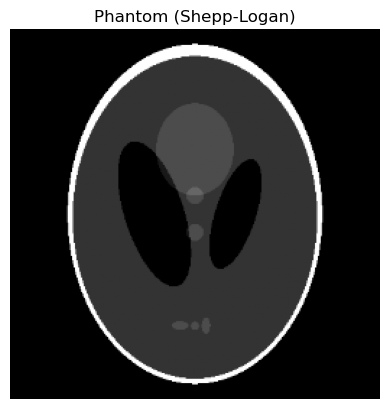

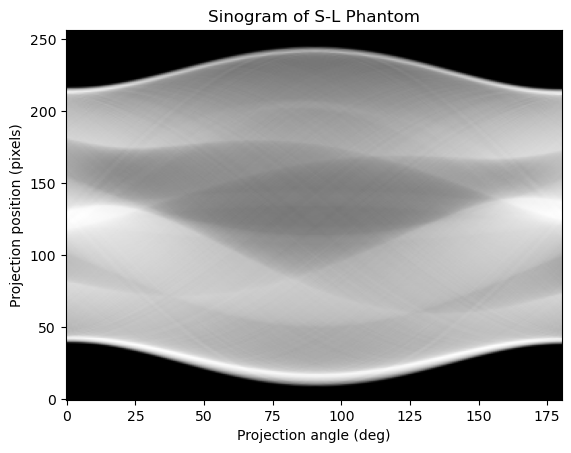

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.data import shepp_logan_phantom
from skimage.transform import resize

phantom = shepp_logan_phantom()
phantom = resize(phantom, (256, 256), mode='reflect', anti_aliasing=True)

plt.imshow(phantom, cmap='gray')
plt.title("Phantom (Shepp-Logan)")
plt.axis('off')
plt.show()

from skimage.transform import radon

max_angle=180.0
theta =  np.linspace(0., max_angle, max(phantom.shape), endpoint=False) # (start, stop, n_samples, don't include endpoint)
sinogram = radon(phantom, theta=theta, circle=True)
dx, dy = 0.5*max_angle/max(phantom.shape), 0.5

plt.imshow(sinogram, cmap=plt.cm.Greys_r, extent=(-dx, max_angle+dx, -dy, sinogram.shape[0]+dy) ,aspect='auto')
plt.title("Sinogram of S-L Phantom")
plt.xlabel("Projection angle (deg)")
plt.ylabel("Projection position (pixels)")
plt.show()

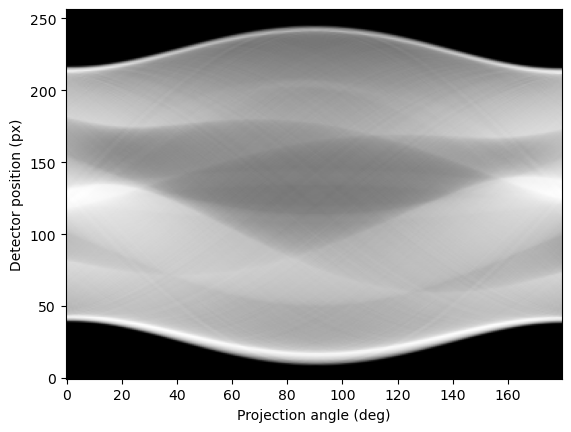

179.296875


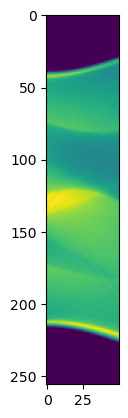

In [50]:
import sys
sys.path.append('..')

from recon import Sinogram

sino = Sinogram(data=sinogram, angles=theta)
sino.plot()
print(sino[-1].angle)
sino[-1]
part = np.zeros([256,50])
ang_part = np.zeros(51)
detector = np.zeros(257)
for idx, proj in  enumerate(sino[0:50]):
    part[:,idx]=proj.values
    ang_part[idx] = proj.angle
    detector[idx] = idx
midpoints = (ang_part[1:] + ang_part[:-1]) / 2
ang_edges = np.concatenate([
    [ang_part[0] - (ang_part[1] - ang_part[0]) / 2],
    midpoints
])

det_edges = np.arange(0.5,len(detector)+0.5,1)

plt.imshow(part)

In [31]:
a=np.zeros([4,8])
a[:,3]
print(a)

[[0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]]


# AcquisitionIndex test

[-179.99993 -179.00003 -178.00014 -177.00025 -176.00036 -175.00047
 -174.00058 -173.00069 -172.0008  -171.00091]
[PosixPath('../data/lab_images/acquisition1/Acc1/raw/Im01_mean.tif'), PosixPath('../data/lab_images/acquisition1/Acc1/raw/Im02_mean.tif'), PosixPath('../data/lab_images/acquisition1/Acc1/raw/Im03_mean.tif'), PosixPath('../data/lab_images/acquisition1/Acc1/raw/Im04_mean.tif'), PosixPath('../data/lab_images/acquisition1/Acc1/raw/Im05_mean.tif'), PosixPath('../data/lab_images/acquisition1/Acc1/raw/Im06_mean.tif'), PosixPath('../data/lab_images/acquisition1/Acc1/raw/Im07_mean.tif'), PosixPath('../data/lab_images/acquisition1/Acc1/raw/Im08_mean.tif'), PosixPath('../data/lab_images/acquisition1/Acc1/raw/Im09_mean.tif'), PosixPath('../data/lab_images/acquisition1/Acc1/raw/Im10_mean.tif')]
step info: AcqisitionStep(filepath=PosixPath('../data/lab_images/acquisition1/Acc1/raw/Im02_mean.tif'), angle=-179.00003)


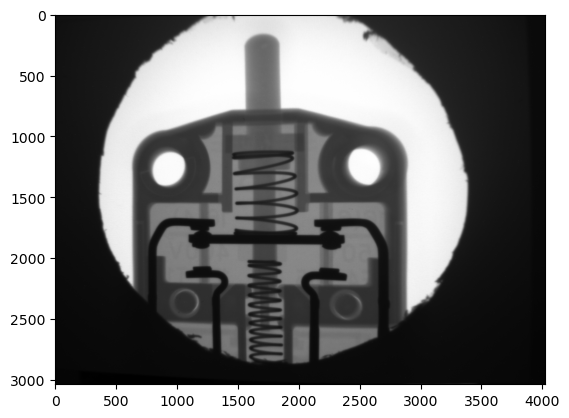

In [1]:
import sys
from skimage import io
sys.path.append('../')
import matplotlib.pyplot as plt
import tifffile as tf

from pathlib import Path, PurePosixPath
from recon import AcquisitionIndex

metafile = Path('../data/lab_images/acquisition1/metadata.txt')
acq = AcquisitionIndex.from_file(metadata_file=metafile)
print(acq._angles[:10])
print(acq._filepaths[:10])

print(f'step info: {acq.steps[1]}')
img = tf.imread(acq.steps[1].filepath)
plt.imshow(img, cmap='grey')


In [2]:
sinogram = acq.create_sinogram(row=1850, crop=(300,3400), max_projections=191)

Creating sinogram from row 1850 of 360 images...
  Loaded Im01_mean.tif, angle=-179.99993 deg, projection shape: (3100,)
  Loaded Im61_mean.tif, angle=-120.00648 deg, projection shape: (3100,)
  Loaded Im121_mean.tif, angle=-60.01304 deg, projection shape: (3100,)
  Loaded Im181_mean.tif, angle=-0.01959 deg, projection shape: (3100,)
Sinogram creation complete. Created 191 projections.


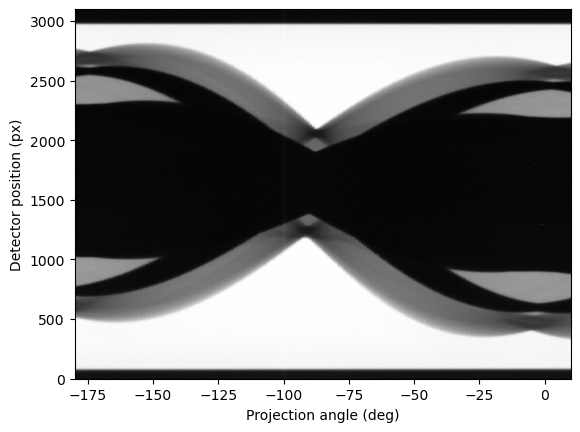

In [3]:
sinogram.plot()

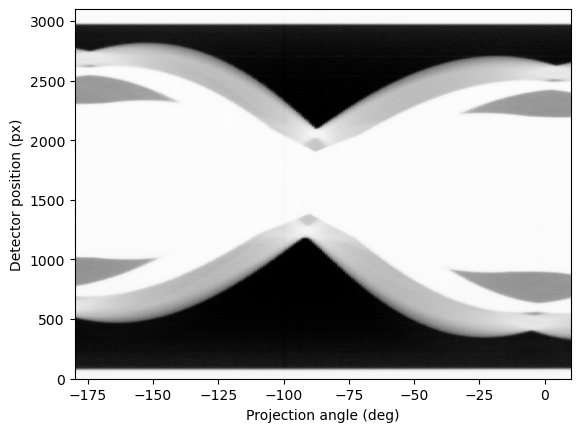

In [7]:
import copy
import numpy as np
inv_sinogram = copy.deepcopy(sinogram)
inv_sinogram._data = np.invert(inv_sinogram._data)
inv_sinogram.plot()

In [8]:
from skimage.transform import iradon
reco = iradon(inv_sinogram._data, theta=inv_sinogram._angles, filter_name='ramp')

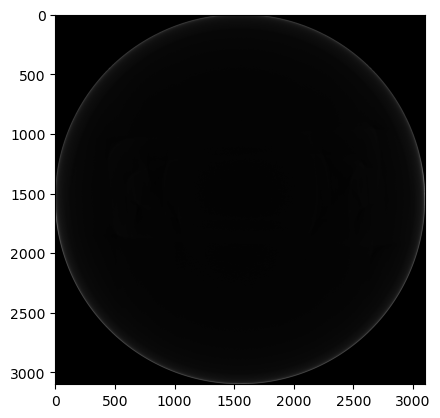

In [9]:
plt.imshow(reco,cmap='gray')

In [10]:
sinogram2 = acq.create_sinogram(row=1200, crop=(300,3400), max_projections=191)

Creating sinogram from row 1200 of 360 images...
  Loaded Im01_mean.tif, angle=-179.99993 deg, projection shape: (3100,)
  Loaded Im61_mean.tif, angle=-120.00648 deg, projection shape: (3100,)
  Loaded Im121_mean.tif, angle=-60.01304 deg, projection shape: (3100,)
  Loaded Im181_mean.tif, angle=-0.01959 deg, projection shape: (3100,)
Sinogram creation complete. Created 191 projections.


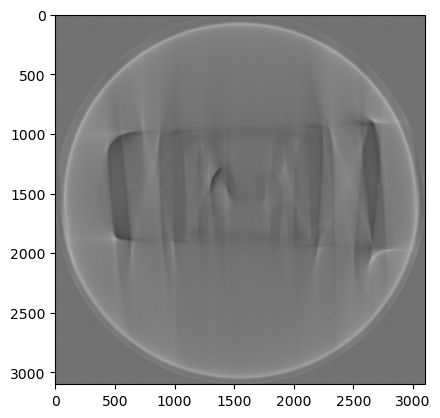

In [12]:
reco2 = iradon(sinogram2._data, theta=sinogram._angles, filter_name='ramp')
plt.imshow(reco2,cmap='gray')

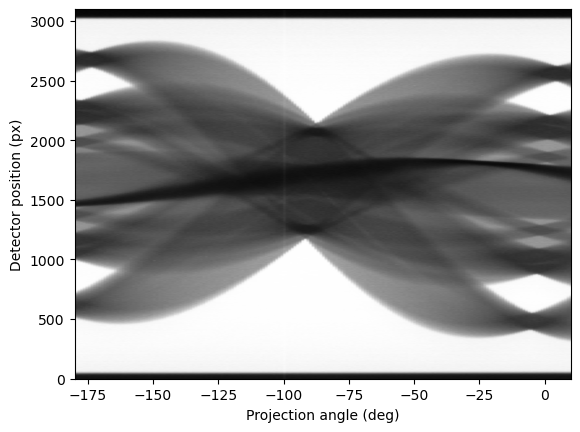

In [16]:
sinogram2.plot()

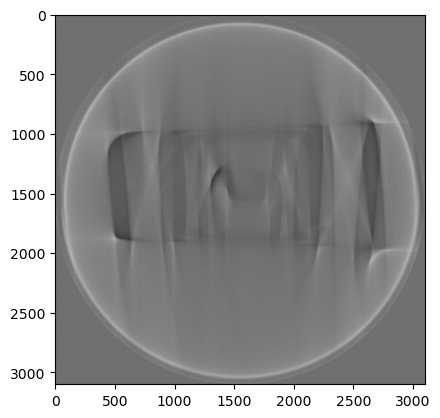

In [17]:
reco2 = iradon(sinogram2._data, theta=sinogram._angles, filter_name='shepp-logan')
plt.imshow(reco2,cmap='gray')

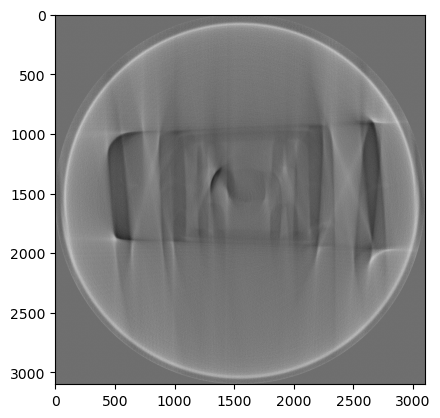

In [18]:
reco2 = iradon(sinogram2._data, theta=sinogram._angles, filter_name='cosine')
plt.imshow(reco2,cmap='gray')

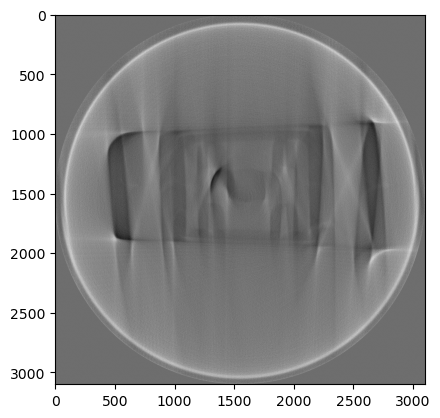

In [19]:
reco2 = iradon(sinogram2._data, theta=sinogram._angles, filter_name='hamming')
plt.imshow(reco2,cmap='gray')

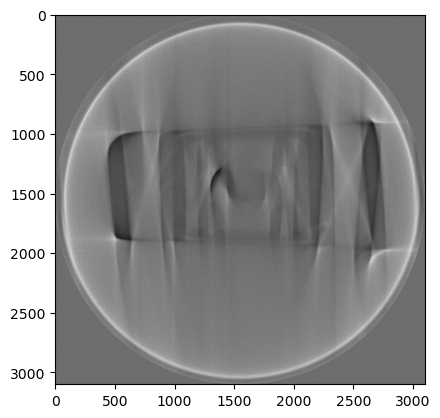

In [20]:
reco2 = iradon(sinogram2._data, theta=sinogram._angles, filter_name='hann')
plt.imshow(reco2,cmap='gray')

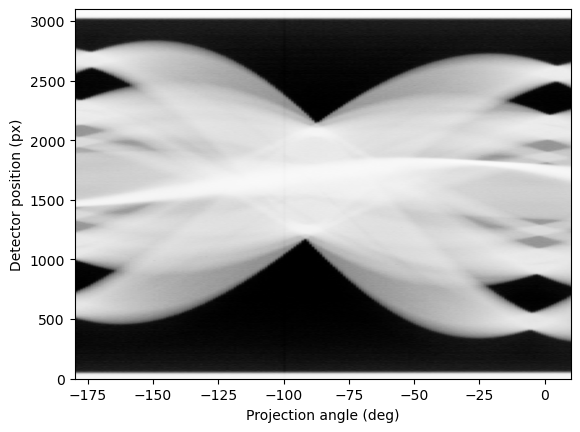

In [24]:
inv_sinogram2 = copy.deepcopy(sinogram2)
inv_sinogram2._data = (2 ** 16 - 1) - sinogram2._data
inv_sinogram2.plot()

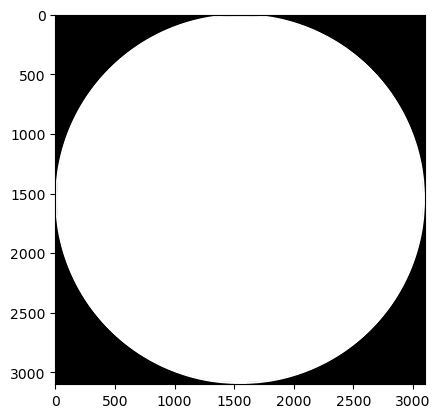

In [26]:
reco2_inv = iradon(inv_sinogram2._data, theta=inv_sinogram._angles, filter_name='hamming')
plt.imshow(reco2_inv,cmap='gray')

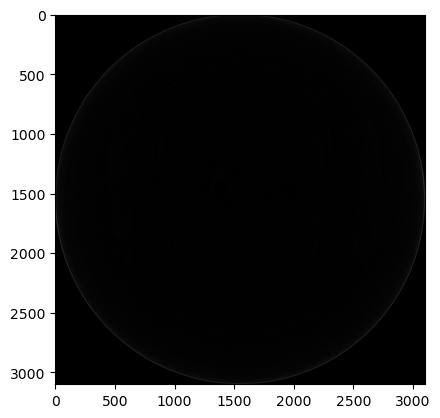

In [27]:
plt.imshow(reco2_inv,cmap='gray',interpolation = 'sinc', vmin = 0, vmax = 2000)